# Loading dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/clean_jobs.csv")

# Creating skill Dictionary

In [27]:
skills = [
    'python',
    'sql',
    'excel',
    'power bi',
    'tableau',
    'aws',
    'azure',
    'gcp',
    'machine learning',
    'deep learning',
    'tensorflow',
    'pytorch',
    'numpy',
    'pandas',
    'scikit-learn',
    'spark',
    'hadoop',
    'nlp',
    'statistics',
    'data visualization'
    'ai',
    'ml',
    'ai/ml',
    'artificial intelligence',
    'data science',
    'data analytics',
    'predictive analytics',
    'computer vision',
    'generative ai',
    'llm',
    'large language model'
    'java',
    'c++',
    'scala',
    'docker',
    'kubernetes',
    'git',
    'linux',
    'airflow',
    'databricks',
    'snowflake',
    'mysql',
    'postgresql',
    'mongodb',
    'etl',
    'big data'
]

# Convert description to lowecase

In [28]:
df['description'] = df['description'].str.lower()

# Extract skills

In [29]:
def extract_skills(description):
    
    found_skills = []

    if pd.isna(description):
        return found_skills

    for skill in skills:
        if skill in description:
            found_skills.append(skill)

    return found_skills

# Applying function

In [30]:
df['skills'] = df['description'].apply(extract_skills)

In [31]:
df[['title','skills']].head()

,title,skills
0,Data Scientist,[machine learning]
1,Data Scientist,[excel]
2,Data Scientist,"[python, sql, excel, numpy, pandas, scikit-lea..."
3,Data Scientist,"[python, sql, excel, numpy, pandas, scikit-lea..."
4,Data Scientist,[excel]


In [32]:
from collections import Counter

all_skills = []

for skill_list in df['skills']:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

skill_counts.most_common(15)

[('ml', 150),
 ('scala', 130),
 ('machine learning', 125),
 ('python', 120),
 ('sql', 61),
 ('llm', 60),
 ('git', 59),
 ('generative ai', 56),
 ('deep learning', 48),
 ('aws', 44),
 ('ai/ml', 40),
 ('excel', 39),
 ('data science', 39),
 ('nlp', 39),
 ('computer vision', 37)]

In [33]:
df['skills'].apply(len).describe()

count    717.000000
mean       1.958159
std        2.105043
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       16.000000
Name: skills, dtype: float64

In [34]:
df['skills'] = df['description'].apply(extract_skills)

In [35]:
df[df['skills'].apply(len) == 0].shape

(209, 7)

# Creating Top Skill Dataframe

In [36]:
top_skills = pd.DataFrame(
    skill_counts.most_common(15),
    columns=['Skill', 'Count']
)

top_skills

,Skill,Count
0,ml,150
1,scala,130
2,machine learning,125
3,python,120
4,sql,61
5,llm,60
6,git,59
7,generative ai,56
8,deep learning,48
9,aws,44


# Visualizing Top 15 Skills

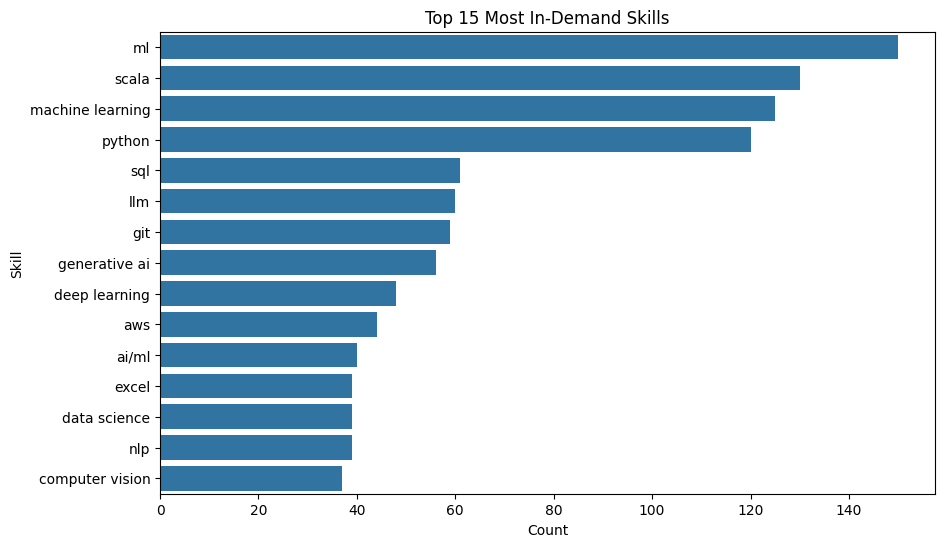

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_skills,
    x='Count',
    y='Skill'
)

plt.title('Top 15 Most In-Demand Skills')
plt.show()

# Extracting Data Scientist Jobs

In [41]:
data_scientist_jobs = df[
    df['title'].str.contains(
        'data scientist',
        case=False,
        na=False
    )
]
all_ds_skills = []

for skill_list in data_scientist_jobs['skills']:
    all_ds_skills.extend(skill_list)

ds_skill_counts = Counter(all_ds_skills)

ds_skill_counts.most_common(10)

[('ml', 20),
 ('machine learning', 19),
 ('python', 13),
 ('data science', 13),
 ('generative ai', 11),
 ('nlp', 9),
 ('scala', 8),
 ('llm', 8),
 ('sql', 6),
 ('excel', 5)]

### Data Scientist Skill Analysis

Machine Learning and Python emerged as the most frequently requested skills for Data Scientist positions. Generative AI, Large Language Models (LLMs), and NLP also appeared prominently, indicating growing demand for AI-focused expertise. SQL remained important but was less frequently mentioned than core machine learning skills.

# Extracting Data Engineer jobs

In [43]:
data_engineer_jobs = df[
    df['title'].str.contains(
        'data engineer',
        case=False,
        na=False
    )
]

all_de_skills = []

for skill_list in data_engineer_jobs['skills']:
    all_de_skills.extend(skill_list)

de_skill_counts = Counter(all_de_skills)

de_skill_counts.most_common(10)

[('scala', 25),
 ('etl', 15),
 ('python', 15),
 ('sql', 15),
 ('azure', 14),
 ('databricks', 13),
 ('spark', 12),
 ('aws', 8),
 ('gcp', 6),
 ('big data', 4)]

# Extracting Data Analyst Jobs

In [44]:
data_analyst_jobs = df[
    df['title'].str.contains(
        'data analyst',
        case=False,
        na=False
    )
]

all_da_skills = []

for skill_list in data_analyst_jobs['skills']:
    all_da_skills.extend(skill_list)

da_skill_counts = Counter(all_da_skills)

da_skill_counts.most_common(10)

[('excel', 7),
 ('data analytics', 7),
 ('git', 7),
 ('sql', 6),
 ('power bi', 6),
 ('ml', 6),
 ('scala', 5),
 ('python', 5),
 ('tableau', 4),
 ('machine learning', 3)]

## Role-Based Skill Analysis

Different job roles require different skill sets.

- Data Scientists primarily require Machine Learning, Python, NLP, and Generative AI skills.
- Data Engineers focus on ETL, Spark, Databricks, SQL, and cloud technologies.
- Data Analysts emphasize Excel, SQL, Power BI, and Tableau for reporting and business intelligence.

These findings highlight the distinct technical requirements across data-related career paths.

In [45]:
df.head()

,title,description,created,company,location,category,skills
0,Data Scientist,overview: the data scientist supports the deve...,2026-04-21T07:36:06Z,v4c.ai,India,IT Jobs,[machine learning]
1,Data Scientist,company description unisynq is redefining engi...,2026-05-06T16:19:14Z,UNISYNQ,"Bangalore, Karnataka",IT Jobs,[excel]
2,Data Scientist,5 years in an analytical position. coding expe...,2026-05-15T09:19:02Z,"Simelabs - Digital, AI/ML, Automation, Robotic...","Kerala, India",IT Jobs,"[python, sql, excel, numpy, pandas, scikit-lea..."
3,Data Scientist,5 years in an analytical position. coding expe...,2026-05-07T16:26:37Z,Astek,"Kochi, Ernakulam",IT Jobs,"[python, sql, excel, numpy, pandas, scikit-lea..."
4,Data Scientist,company description flexi roundtables: top 1% ...,2026-05-22T17:50:56Z,Flexi Roundtables : Top 1% Leaders,India,IT Jobs,[excel]


In [46]:
df.to_csv(
    '../data/processed/jobs_with_skills.csv',
    index=False
)